# Watlow YOLOv8 — Test avec Dataset Équilibré + Meilleurs Hyperparamètres

Ce notebook teste l'effet du **dataset équilibré** (augmentation manuelle par classe :
OK ×3, pclipAbsent ×4, ticketManquant ×7) combiné aux **meilleurs hyperparamètres**
trouvés en tuning (sélection automatique du trial avec le mAP50 le plus élevé,
toutes pistes confondues, en base Supabase).

**Choix d'augmentation online** : mosaic/mixup désactivés (incohérents avec un
dataset déjà augmenté manuellement — mélanger des images déjà transformées n'a
pas de sens physique pour de l'inspection de défauts). fliplr/degrees légers
conservés (variabilité saine, sans risque, cohérents avec les bornes utilisées
pour l'augmentation manuelle elle-même).

⚠️ Avant de lancer :
1. Upload le dataset équilibré (3 dossiers fusionnés + valid/ inchangé) via Add Input
2. Vérifie que les .txt ont été nettoyés (`fix_labels_float_classes.py`) si besoin
3. Internet activé + SUPABASE_URL/KEY remplis


In [1]:
# ─────────────────────────────────────────────
# 0. SETUP & INSTALLATION
# ─────────────────────────────────────────────
!pip install ultralytics optuna optuna-dashboard plotly supabase squarify -q

import os, json, time, glob
import torch
import optuna
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from ultralytics import YOLO
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

sns.set_style('darkgrid')
%matplotlib inline

print("GPU disponible :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Aucun")
torch.cuda.empty_cache()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 67.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 require

In [2]:
# ─────────────────────────────────────────────
# 1. CHEMINS + CONFIGURATION — Dataset ÉQUILIBRÉ
# ─────────────────────────────────────────────
DATA_YAML   = '/kaggle/input/datasets/amanakhachnaoui/augmentedwatlow/Dataset/data.yaml'   # ⚠️ adapte le nom
PROJECT_DIR = '/kaggle/working/runs'

BASE_MODEL   = 'yolov8s.pt'   # ⚠️ adapte selon le best trial réellement choisi en base
TARGET_IMGSZ = 640
TARGET_BATCH = 32

RUN_NAME = f"balanced_dataset_{BASE_MODEL.replace('.pt','')}_{TARGET_IMGSZ}"

import os
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Config active : {BASE_MODEL} | imgsz={TARGET_IMGSZ} | batch={TARGET_BATCH}")
print(f"RUN_NAME = {RUN_NAME}")


Config active : yolov8s.pt | imgsz=640 | batch=32
RUN_NAME = balanced_dataset_yolov8s_640


In [3]:
# ─────────────────────────────────────────────
# 2. SUPABASE — connexion + VÉRIFICATION DE SCHÉMA RÉELLE + logging fiable
#    ⚠️ La vérification teste un VRAI insert avec des floats sur toutes les
#    colonnes numériques — pas juste "la colonne existe". C'est ce test qui
#    aurait attrapé le bug "invalid input syntax for type integer: 32.0"
#    avant de lancer 30 trials dans le vide.
# ─────────────────────────────────────────────
from supabase import create_client

SUPABASE_URL = "https://ulqplsoygzpgxxlkvnyn.supabase.co"   # ← remplace par ton Project URL
SUPABASE_KEY = "sb_publishable_HJhCOpIKG191kolPuCkskw_qfIQqE7X"                # ← remplace par ta clé publishable/anon

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)


def check_schema_real_insert():
    """Teste un insert REEL (puis le supprime) sur chaque table, avec des
    valeurs float sur tous les champs numeriques. Si Postgres a une colonne
    en int strict, l'insert echoue ici - pas apres 30 trials calcules."""
    tests = {
        "optuna_trials": {
            "trial_number": -999, "model_variant": "schema_test", "phase": "schema_test",
            "epochs": 30.0, "imgsz": 640.0, "batch_size": 32.0,
            "lr0": 0.01, "lrf": 0.01, "momentum": 0.9, "weight_decay": 0.0005,
            "warmup_epochs": 3.0, "box": 7.5, "cls": 0.5, "mosaic": 0.5,
            "mixup": 0.1, "degrees": 0.0, "fliplr": 0.5,
            "map50": 0.0, "status": "test", "is_best": False,
        },
        "training_runs": {
            "run_name": "schema_test", "model_variant": "schema_test",
            "epoch": 1.0, "total_epochs": 100.0, "batch_size": 32.0, "imgsz": 640.0,
            "lr0": 0.01, "weight_decay": 0.0005,
            "precision": 0.5, "recall": 0.5, "map50": 0.5, "map50_95": 0.5,
            "status": "test",
        },
        "class_metrics": {
            "run_name": "schema_test", "class_name": "schema_test",
            "precision": 0.5, "recall": 0.5, "map50": 0.5, "map50_95": 0.5,
        },
    }

    all_ok = True
    for table, record in tests.items():
        try:
            res = supabase.table(table).insert(record).execute()
            if res.data:
                supabase.table(table).delete().eq("id", res.data[0]["id"]).execute()
                print(f"OK Table '{table}' - accepte les floats sur tous les champs numeriques.")
            else:
                print(f"ECHEC Table '{table}' - insert n'a retourne aucune ligne (suspect).")
                all_ok = False
        except Exception as e:
            print(f"ECHEC Table '{table}' : {e}")
            all_ok = False
    return all_ok


print("Verification du schema Supabase (insert reel avec floats)...")
schema_ok = check_schema_real_insert()
if not schema_ok:
    raise RuntimeError(
        "Schema Supabase incompatible - corrige les types de colonnes "
        "(probablement int vers float8 sur une colonne numerique) AVANT de "
        "continuer. Le notebook s'arrete pour ne pas perdre de resultats "
        "silencieusement, comme c'est arrive avec batch_size la derniere fois."
    )
print("\nSchema valide - sauvegarde garantie pour ce run.\n")


def _clean_numeric(d: dict) -> dict:
    out = {}
    for k, v in d.items():
        if isinstance(v, bool):
            out[k] = v
        elif isinstance(v, (int, float)):
            out[k] = float(v)
        else:
            out[k] = v
    return out


def log_with_retry(table: str, record: dict, max_retries=3, label=""):
    """Insertion generique avec retry + verification visible."""
    record = _clean_numeric(record)
    for attempt in range(1, max_retries + 1):
        try:
            res = supabase.table(table).insert(record).execute()
            if res.data:
                return True
            raise ValueError("insert n'a retourne aucune ligne")
        except Exception as e:
            if attempt < max_retries:
                time.sleep(2 * attempt)
            else:
                print(f"   ECHEC DEFINITIF ({table}, {label}) apres {max_retries} tentatives : {e}")
                print(f"        Valeurs a noter manuellement : {record}")
                return False
    return False


def log_trial_to_supabase(trial_number, map50, params, phase, status="completed", notes=""):
    record = {
        "trial_number": int(trial_number),
        "model_variant": BASE_MODEL.replace(".pt", ""),
        "phase": phase,
        "epochs": params.get("epochs"),
        "imgsz": params.get("imgsz"),
        "batch_size": params.get("batch"),
        "lr0": params.get("lr0"), "lrf": params.get("lrf"),
        "momentum": params.get("momentum"), "weight_decay": params.get("weight_decay"),
        "warmup_epochs": params.get("warmup_epochs"),
        "box": params.get("box"), "cls": params.get("cls"),
        "mosaic": params.get("mosaic"), "mixup": params.get("mixup"),
        "degrees": params.get("degrees"), "fliplr": params.get("fliplr"),
        "map50": float(map50), "status": status, "is_best": False, "notes": notes,
    }
    ok = log_with_retry("optuna_trials", record, label=f"trial {trial_number}")
    print(f"   {'CONFIRME' if ok else 'ECHEC'} - Trial {trial_number} ({phase}) mAP50={map50:.4f}")
    return ok


def mark_best_trial_in_supabase(best_trial_number):
    """Marque is_best=true - avec VERIFICATION que la ligne a vraiment ete
    trouvee et modifiee (un update Postgres reussit silencieusement meme a
    0 lignes affectees, donc on ne peut pas faire confiance a l'absence
    d'exception comme preuve de succes)."""
    try:
        supabase.table("optuna_trials").update({"is_best": False}).eq("phase", "optuna_phase2").execute()
        res = supabase.table("optuna_trials").update({"is_best": True}).eq(
            "trial_number", int(best_trial_number)).eq("phase", "optuna_phase2").execute()
        if res.data and len(res.data) > 0:
            print(f"CONFIRME - Trial #{best_trial_number} marque is_best=true ({len(res.data)} ligne(s) modifiee(s)).")
        else:
            print(f"ATTENTION : l'update n'a modifie AUCUNE ligne pour le trial #{best_trial_number}. "
                  f"Le trial n'existe probablement pas en base sous ce numero/phase - "
                  f"verifie qu'il a bien ete insere avant d'appeler cette fonction.")
    except Exception as e:
        print("Erreur lors du marquage is_best :", e)


def log_epoch_to_supabase(epoch, total_epochs, metrics_dict, status="running", notes=""):
    record = {
        "run_name": RUN_NAME, "model_variant": BASE_MODEL.replace(".pt", ""),
        "epoch": epoch, "total_epochs": total_epochs,
        "batch_size": TARGET_BATCH, "imgsz": TARGET_IMGSZ,
        **metrics_dict, "status": status, "notes": notes,
    }
    return log_with_retry("training_runs", record, label=f"epoch {epoch}")


print(f"Helpers Supabase prets - RUN_NAME={RUN_NAME}")


Verification du schema Supabase (insert reel avec floats)...
OK Table 'optuna_trials' - accepte les floats sur tous les champs numeriques.
OK Table 'training_runs' - accepte les floats sur tous les champs numeriques.
OK Table 'class_metrics' - accepte les floats sur tous les champs numeriques.

Schema valide - sauvegarde garantie pour ce run.

Helpers Supabase prets - RUN_NAME=balanced_dataset_yolov8s_640


In [4]:
# ─────────────────────────────────────────────
# 2. MEILLEURS HYPERPARAMÈTRES — récupérés depuis Supabase
#    Cherche le mAP50 le plus élevé TOUTES PISTES confondues (nano/1280 ET small/640).
# ─────────────────────────────────────────────
HYPERPARAM_KEYS = ["lr0", "lrf", "momentum", "weight_decay", "warmup_epochs",
                   "box", "cls", "mosaic", "mixup", "degrees", "fliplr"]

FALLBACK_BEST_PARAMS = {
    "lr0": 0.010272997232892668, "lrf": 0.02052119030652367,
    "momentum": 0.8508918242648488, "weight_decay": 0.0003448178439164303,
    "warmup_epochs": 1, "box": 6.521211214797688, "cls": 0.9297077179586855,
    "mosaic": 0.602362, "mixup": 0.087369, "degrees": 9.177793, "fliplr": 0.355798,
}
FALLBACK_TRIAL_NUMBER = 1
FALLBACK_MAP50 = 0.8402

def get_best_hyperparameters():
    try:
        response = (
            supabase.table("optuna_trials")
            .select("*")
            .eq("phase", "optuna_phase2")
            .order("map50", desc=True)
            .limit(1)
            .execute()
        )
        if not response.data:
            raise ValueError("Table optuna_trials vide")
        row = response.data[0]
        params = {k: row[k] for k in HYPERPARAM_KEYS if row.get(k) is not None}
        return params, row["trial_number"], row["map50"], row.get("model_variant", "?"), "supabase"
    except Exception as e:
        print(f"⚠️ Impossible de lire Supabase ({e}) — utilisation du fallback local.")
        return FALLBACK_BEST_PARAMS, FALLBACK_TRIAL_NUMBER, FALLBACK_MAP50, "yolov8s", "fallback_local"

best_params, best_trial_number, best_map50_tuning, best_model_variant, source = get_best_hyperparameters()

print(f"📋 Best hyperparameters — Trial #{best_trial_number} "
      f"(model={best_model_variant}, mAP50 tuning={best_map50_tuning:.4f}, source={source})")
for k, v in best_params.items():
    print(f"   {k}: {v}")

if best_model_variant != BASE_MODEL.replace(".pt", ""):
    print(f"\n⚠️ ATTENTION : le best trial vient de '{best_model_variant}' mais BASE_MODEL="
          f"'{BASE_MODEL}'. Les hyperparamètres restent appliqués (transférabilité partielle "
          f"attendue), mais garde ce point en tête en interprétant les résultats.")


📋 Best hyperparameters — Trial #1 (model=yolov8s, mAP50 tuning=0.8402, source=supabase)
   lr0: 0.0102729972328927
   lrf: 0.0205211903065237
   momentum: 0.850891824264849
   weight_decay: 0.00034481784391643
   warmup_epochs: 1
   box: 6.52121121479769
   cls: 0.929707717958685
   mosaic: 0.602361513049481
   mixup: 0.0873687420594126
   degrees: 9.17779342083569
   fliplr: 0.355797544260817


In [5]:
# ─────────────────────────────────────────────
# 3. AJUSTEMENT — désactive mosaic/mixup (incohérent avec dataset déjà augmenté),
#    garde fliplr/degrees (légers, sans risque)
# ─────────────────────────────────────────────
best_params_adjusted = dict(best_params)
best_params_adjusted["mosaic"] = 0.0
best_params_adjusted["mixup"]  = 0.0
# fliplr et degrees restent tels que trouvés par le tuning

print("📋 Hyperparamètres ajustés pour ce run (dataset déjà augmenté) :")
for k, v in best_params_adjusted.items():
    flag = "  ← désactivé (dataset déjà augmenté)" if k in ("mosaic", "mixup") else ""
    print(f"   {k}: {v}{flag}")


📋 Hyperparamètres ajustés pour ce run (dataset déjà augmenté) :
   lr0: 0.0102729972328927
   lrf: 0.0205211903065237
   momentum: 0.850891824264849
   weight_decay: 0.00034481784391643
   warmup_epochs: 1
   box: 6.52121121479769
   cls: 0.929707717958685
   mosaic: 0.0  ← désactivé (dataset déjà augmenté)
   mixup: 0.0  ← désactivé (dataset déjà augmenté)
   degrees: 9.17779342083569
   fliplr: 0.355797544260817


In [6]:
# ─────────────────────────────────────────────
# 4. ENTRAÎNEMENT FINAL — Dataset équilibré + best hyperparameters ajustés
# ─────────────────────────────────────────────
import time, torch
from ultralytics import YOLO

FINAL_EPOCHS = 100

model = YOLO(BASE_MODEL)

def on_fit_epoch_end(trainer):
    m = trainer.metrics
    metrics_dict = {
        "lr0": trainer.args.lr0,
        "weight_decay": trainer.args.weight_decay,
        "precision": float(m.get("metrics/precision(B)", 0)),
        "recall": float(m.get("metrics/recall(B)", 0)),
        "map50": float(m.get("metrics/mAP50(B)", 0)),
        "map50_95": float(m.get("metrics/mAP50-95(B)", 0)),
    }
    log_epoch_to_supabase(trainer.epoch + 1, trainer.epochs, metrics_dict, status="running")

model.add_callback("on_fit_epoch_end", on_fit_epoch_end)
torch.cuda.empty_cache()

log_epoch_to_supabase(0, FINAL_EPOCHS, {}, status="started",
                       notes=f"Dataset équilibré (OK/pclipAbsent/ticketManquant augmentés) — "
                             f"hyperparams trial #{best_trial_number} ({best_model_variant}, "
                             f"mAP50 tuning={best_map50_tuning:.4f}) — mosaic/mixup désactivés")

t0 = time.time()

results = model.train(
    data=DATA_YAML, epochs=FINAL_EPOCHS, imgsz=TARGET_IMGSZ, batch=TARGET_BATCH,
    project=PROJECT_DIR, name=RUN_NAME, seed=42, workers=4, device=0,
    rect=True, patience=20, conf=0.45, save=True, plots=True,

    # augmentation online : explicitement désactivée/réduite (dataset déjà augmenté)
    augment=True,          # garde le pipeline d'augmentation actif...
    mosaic=best_params_adjusted["mosaic"],   # ...mais mosaic à 0
    mixup=best_params_adjusted["mixup"],     # ...et mixup à 0
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,          # pas de re-jitter couleur (déjà fait manuellement)
    translate=0.0, scale=0.0,                 # pas de re-translation/zoom (déjà fait manuellement)
    fliplr=best_params_adjusted["fliplr"],    # léger flip résiduel conservé
    degrees=best_params_adjusted["degrees"],  # légère rotation résiduelle conservée

    lr0=best_params_adjusted["lr0"], lrf=best_params_adjusted["lrf"],
    momentum=best_params_adjusted["momentum"], weight_decay=best_params_adjusted["weight_decay"],
    warmup_epochs=best_params_adjusted["warmup_epochs"],
    box=best_params_adjusted["box"], cls=best_params_adjusted["cls"],
)

elapsed = time.time() - t0
rd = results.results_dict

log_epoch_to_supabase(
    FINAL_EPOCHS, FINAL_EPOCHS,
    {
        "precision": float(rd.get("metrics/precision(B)", 0)),
        "recall": float(rd.get("metrics/recall(B)", 0)),
        "map50": float(rd.get("metrics/mAP50(B)", 0)),
        "map50_95": float(rd.get("metrics/mAP50-95(B)", 0)),
    },
    status="completed",
    notes=f"Dataset équilibré — Durée: {elapsed/60:.1f} min",
)

print("\n" + "="*60)
print("RÉSULTATS FINAUX — DATASET ÉQUILIBRÉ")
print("="*60)
print(f"  mAP50    : {rd.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP50-95 : {rd.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision: {rd.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall   : {rd.get('metrics/recall(B)', 0):.4f}")
print(f"\n📁 Modèle : {PROJECT_DIR}/{RUN_NAME}/weights/best.pt")


Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=6.52121121479769, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.929707717958685, cls_pw=0.0, compile=False, conf=0.45, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/amanakhachnaoui/augmentedwatlow/Dataset/data.yaml, degrees=9.17779342083569, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.355797544260817, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0102729972328927, lrf=0.0205211903065237, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.850891824264849,

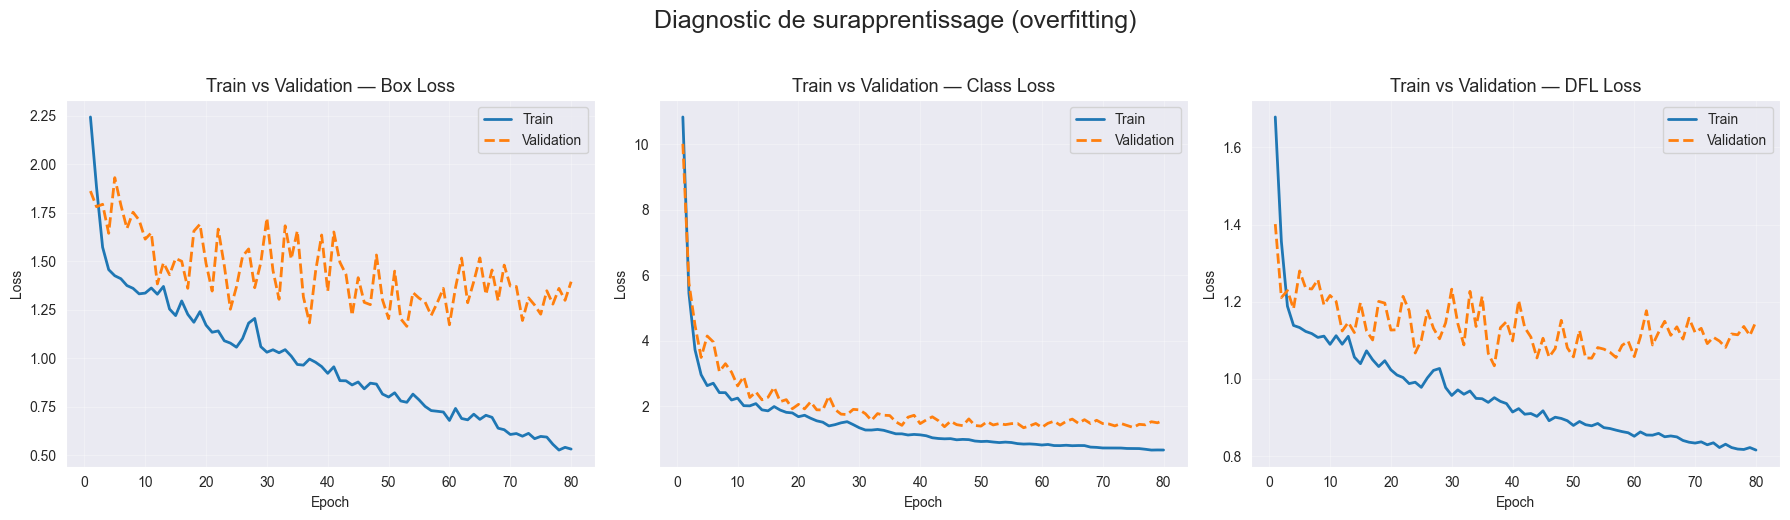


📊 Écart train/validation à la dernière epoch :
   Box Loss    : train=0.532  val=1.395  écart=+0.863 (+162%)  ⚠️ surapprentissage possible
   Class Loss  : train=0.658  val=1.567  écart=+0.909 (+138%)  ⚠️ surapprentissage possible
   DFL Loss    : train=0.816  val=1.149  écart=+0.333 (+41%)  ✅ écart raisonnable

🎯 Meilleur mAP50 atteint à l'epoch 62 (valeur=0.8395) / 80 epochs entraînées


In [7]:
# ─────────────────────────────────────────────
# 8. COURBES TRAIN vs VALIDATION — diagnostic de surapprentissage
# ─────────────────────────────────────────────
df = pd.read_csv(f'{PROJECT_DIR}/{RUN_NAME}/results.csv')
df.columns = df.columns.str.strip()

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
loss_pairs = [("box_loss", "Box Loss"), ("cls_loss", "Class Loss"), ("dfl_loss", "DFL Loss")]

for ax, (loss_key, title) in zip(axs, loss_pairs):
    ax.plot(df["epoch"], df[f"train/{loss_key}"], label="Train", linewidth=2)
    ax.plot(df["epoch"], df[f"val/{loss_key}"], label="Validation", linewidth=2, linestyle="--")
    ax.set_title(f"Train vs Validation — {title}", fontsize=13)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Diagnostic de surapprentissage (overfitting)", fontsize=18, y=1.03)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/{RUN_NAME}/train_vs_val_curves.png', dpi=120, bbox_inches='tight')
plt.show()

last = df.iloc[-1]
print("\n📊 Écart train/validation à la dernière epoch :")
for loss_key, title in loss_pairs:
    gap = last[f"val/{loss_key}"] - last[f"train/{loss_key}"]
    pct = (gap / last[f"train/{loss_key}"] * 100) if last[f"train/{loss_key}"] else 0
    flag = "⚠️ surapprentissage possible" if pct > 50 else "✅ écart raisonnable"
    print(f"   {title:12s}: train={last[f'train/{loss_key}']:.3f}  val={last[f'val/{loss_key}']:.3f}  écart={gap:+.3f} ({pct:+.0f}%)  {flag}")

best_epoch = int(df.loc[df["metrics/mAP50(B)"].idxmax(), "epoch"])
print(f"\n🎯 Meilleur mAP50 atteint à l'epoch {best_epoch} (valeur={df['metrics/mAP50(B)'].max():.4f}) / {int(df['epoch'].max())} epochs entraînées")


In [8]:
# ─────────────────────────────────────────────
# 9. MÉTRIQUES PAR CLASSE → Supabase
# ─────────────────────────────────────────────
metrics = model.val(conf=0.25, data=DATA_YAML)
class_names = model.names

per_class_records = []
print("📋 Métriques par classe :")
for i, class_id in enumerate(metrics.box.ap_class_index):
    name = class_names[int(class_id)]
    p, r = float(metrics.box.p[i]), float(metrics.box.r[i])
    ap50, ap = float(metrics.box.ap50[i]), float(metrics.box.ap[i])
    print(f"   {name:22s}  P={p:.3f}  R={r:.3f}  mAP50={ap50:.3f}  mAP50-95={ap:.3f}")
    per_class_records.append({"run_name": RUN_NAME, "class_name": name,
                               "precision": p, "recall": r, "map50": ap50, "map50_95": ap})

for rec in per_class_records:
    log_with_retry("class_metrics", rec, label=rec["class_name"])

CRITICAL_CLASS = "p_clip_NOK"
crit = next((r for r in per_class_records if r["class_name"] == CRITICAL_CLASS), None)
if crit:
    print(f"\n🔍 Classe critique '{CRITICAL_CLASS}' : Recall={crit['recall']:.3f} | mAP50={crit['map50']:.3f}")


Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,129,841 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1240.4±521.0 MB/s, size: 2406.9 KB)
val: Scanning /kaggle/input/datasets/amanakhachnaoui/augmentedwatlow/Dataset/valid/labels... 24 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 209.6it/s 0.1s
val: /kaggle/input/datasets/amanakhachnaoui/augmentedwatlow/Dataset/valid/images/IMG_1842_jpg.rf.iPrYiuGd3DY4juNNxqTK.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/amanakhachnaoui/augmentedwatlow/Dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.1s
                   all         24        308      0.883      0.861      0.853      0.514
             Etiquette         13         22          1      0.955      0.955    

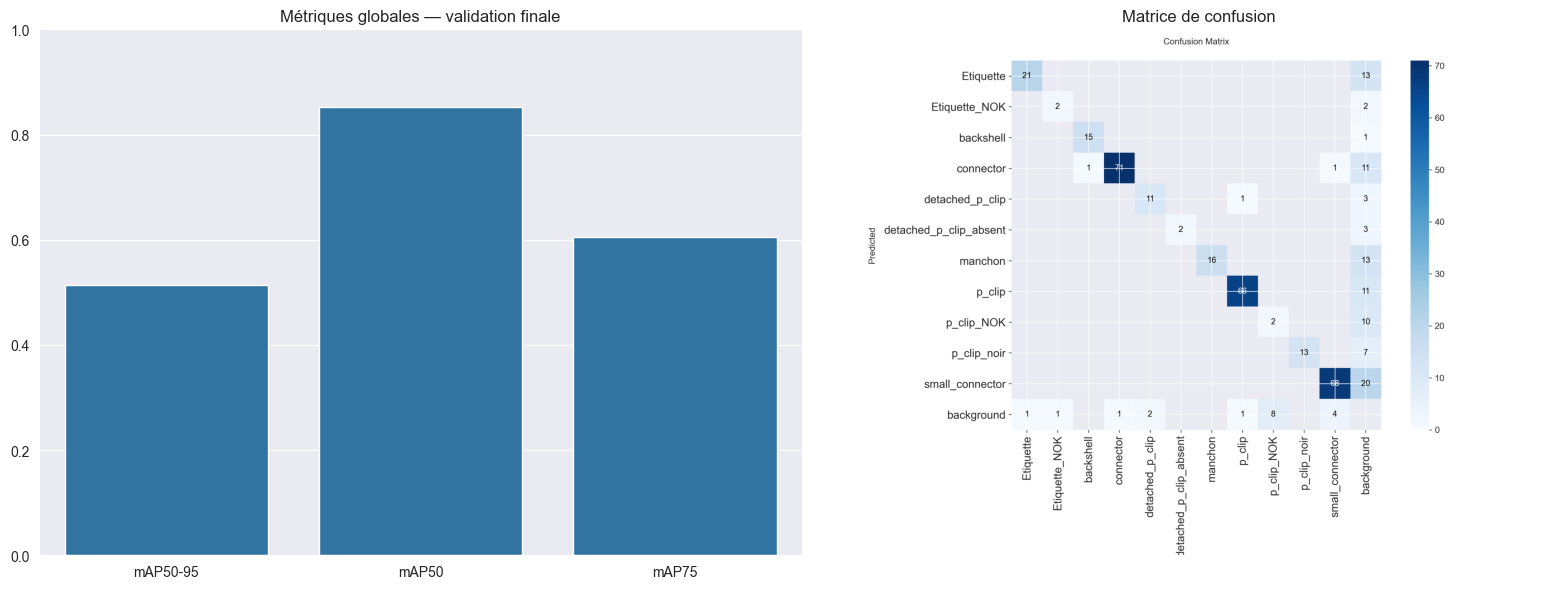

In [9]:
# ─────────────────────────────────────────────
# 10. BARPLOT mAP + MATRICE DE CONFUSION
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=['mAP50-95', 'mAP50', 'mAP75'],
            y=[metrics.box.map, metrics.box.map50, metrics.box.map75],
            ax=axes[0])
axes[0].set_title("Métriques globales — validation finale")
axes[0].set_ylim(0, 1)

cm_path = f'{PROJECT_DIR}/{RUN_NAME}/confusion_matrix.png'
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    axes[1].imshow(img); axes[1].axis('off'); axes[1].set_title("Matrice de confusion")
else:
    axes[1].text(0.5, 0.5, "confusion_matrix.png introuvable", ha='center')

plt.tight_layout()
plt.show()


In [10]:
# ─────────────────────────────────────────────
# 11. COMPARAISON AUTOMATIQUE — ce run vs référence projet vs meilleur run précédent
# ─────────────────────────────────────────────
current = {
    "map50": float(rd.get("metrics/mAP50(B)", 0)),
    "map50_95": float(rd.get("metrics/mAP50-95(B)", 0)),
    "precision": float(rd.get("metrics/precision(B)", 0)),
    "recall": float(rd.get("metrics/recall(B)", 0)),
}
REFERENCE_MAP50 = 0.912   # référence historique YOLOv8s/640 (run "train-13")

try:
    resp = (supabase.table("training_runs").select("run_name, map50, map50_95, precision, recall, status")
            .eq("status", "completed").neq("run_name", RUN_NAME).order("map50", desc=True).limit(1).execute())
    prev_best = resp.data[0] if resp.data else None
except Exception as e:
    print("⚠️ Erreur lecture Supabase :", e)
    prev_best = None

print("="*60); print("COMPARAISON AUTOMATIQUE"); print("="*60)
print(f"\nRun courant ({RUN_NAME}) : mAP50={current['map50']:.4f}  mAP50-95={current['map50_95']:.4f}  "
      f"P={current['precision']:.4f}  R={current['recall']:.4f}")

delta_ref = current["map50"] - REFERENCE_MAP50
verdict_ref = "🟢 AMÉLIORATION" if delta_ref > 0.005 else ("🟡 ÉQUIVALENT" if abs(delta_ref) <= 0.005 else "🔴 RÉGRESSION")
print(f"\nvs référence projet (mAP50={REFERENCE_MAP50:.3f}) : Δ={delta_ref:+.4f} → {verdict_ref}")

if prev_best:
    delta_prev = current["map50"] - prev_best["map50"]
    verdict_prev = "🟢 AMÉLIORATION" if delta_prev > 0.005 else ("🟡 ÉQUIVALENT" if abs(delta_prev) <= 0.005 else "🔴 RÉGRESSION")
    prev_name = prev_best["run_name"]
    prev_map50 = prev_best["map50"]
    print(f"vs meilleur run précédent ('{prev_name}', mAP50={prev_map50:.4f}) : Δ={delta_prev:+.4f} → {verdict_prev}")
else:
    print("(Aucun run précédent terminé dans Supabase — ce run devient la référence.)")


COMPARAISON AUTOMATIQUE

Run courant (balanced_dataset_yolov8s_640) : mAP50=0.8092  mAP50-95=0.4614  P=0.8197  R=0.7922

vs référence projet (mAP50=0.912) : Δ=-0.1028 → 🔴 RÉGRESSION
(Aucun run précédent terminé dans Supabase — ce run devient la référence.)
